<a href="https://colab.research.google.com/github/arcctg/kpi-ml-lab5/blob/main/02_cifar10_object_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: CIFAR-10 Object Classification


#### Importing Required Libraries

We import the following libraries:
- **numpy (np)**: Array operations — reshaping, argmax, random sampling
- **matplotlib.pyplot (plt)**: Plotting images, training curves, and prediction charts
- **tensorflow (tf)**: Deep-learning backend powering Keras
- **tensorflow.keras.datasets.cifar10**: Built-in loader for CIFAR-10 (50 000 train + 10 000 test **colour** images, 32×32×3)
- **tensorflow.keras.utils.to_categorical**: One-hot encoding for multi-class labels
- **tensorflow.keras.models / layers**: High-level API for building CNN architectures with `Conv2D`, `MaxPooling2D`, `BatchNormalization`, `Dropout`, `RandomFlip`, `RandomRotation`, `Flatten`, and `Dense` layers
- **tensorflow.keras.callbacks.EarlyStopping**: Callback that stops training when validation loss stops improving

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


#### Loading the CIFAR-10 Dataset

CIFAR-10 is a widely-used benchmark dataset for image classification, bundled inside Keras.

Key characteristics:
- **50 000 training** + **10 000 test** images
- **RGB colour** images of size **32 × 32 × 3** (3 channels)
- **10 mutually exclusive classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- Pixel values are `uint8` in **[0, 255]**
- Labels are integers in **[0, 9]**

Compared to MNIST, CIFAR-10 is significantly harder: images are low-resolution colour photographs of real-world objects with complex backgrounds, not clean handwritten digits on a blank canvas.

In [2]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training set — images:", train_images.shape, "| labels:", train_labels.shape)
print("Test set     — images:", test_images.shape,  "| labels:", test_labels.shape)
print("Data type:", train_images.dtype)
print("Pixel value range: [{}, {}]".format(train_images.min(), train_images.max()))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training set — images: (50000, 32, 32, 3) | labels: (50000, 1)
Test set     — images: (10000, 32, 32, 3) | labels: (10000, 1)
Data type: uint8
Pixel value range: [0, 255]


#### Visualising the First 25 Training Images

We display a 5 × 5 grid of the first 25 training images with their class names.

This serves two purposes:
1. **Sanity check** — confirms data loaded correctly and labels match the visible content
2. **Intuition** — shows the variety and low resolution (32×32) of CIFAR-10. Many images are hard to classify even for humans at this resolution.

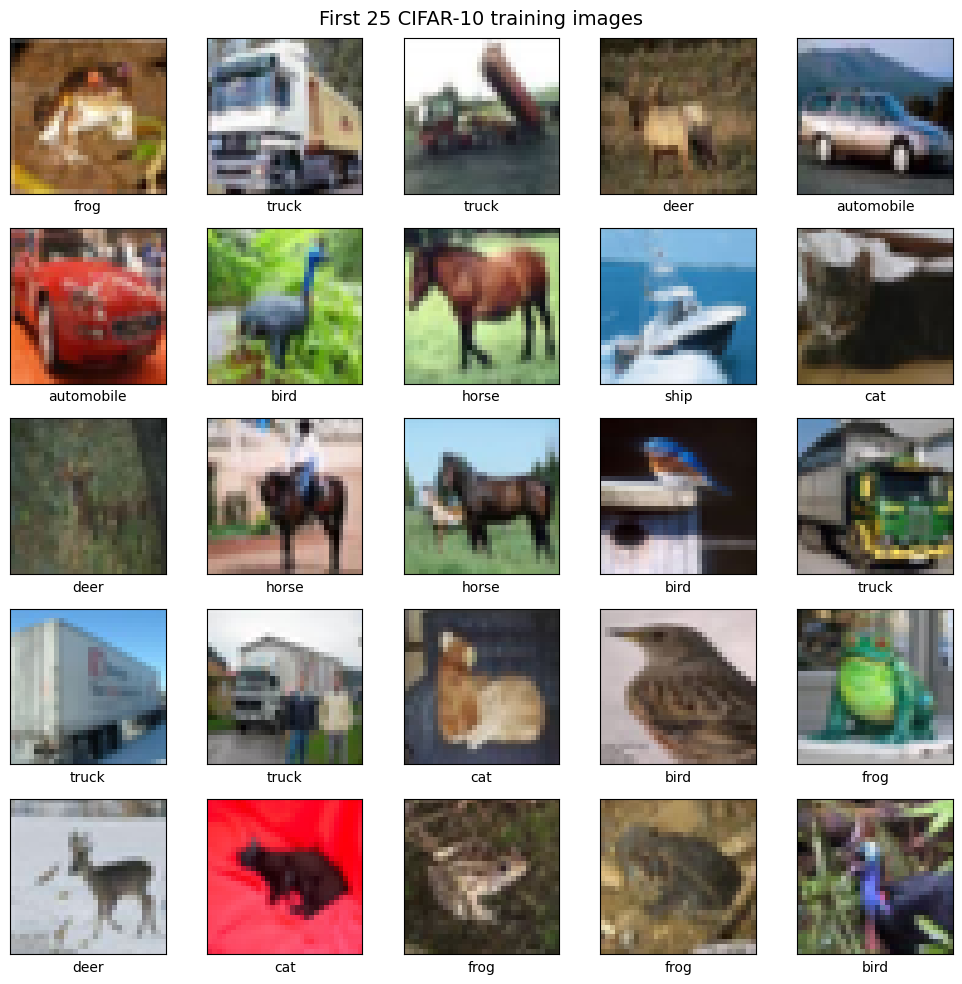

In [3]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.suptitle("First 25 CIFAR-10 training images", fontsize=14)
plt.tight_layout()
plt.show()

#### Data Preprocessing

**1. Normalise pixel values to [0, 1]**
Divide by 255 and cast to `float32`. This keeps inputs in the same numeric range as the initial random weights, greatly accelerating gradient convergence.

**2. One-hot encode labels**
`to_categorical` converts each integer label to a binary vector of length 10, as required by `categorical_crossentropy`.

**Important:** Unlike MNIST, we do **not** flatten the images. Convolutional layers expect the full spatial shape `(32, 32, 3)` to detect local patterns (edges, textures, shapes) via sliding filters.

In [4]:
# Normalise
train_images = train_images.astype('float32') / 255
test_images  = test_images.astype('float32') / 255

# One-hot encode labels
train_labels = to_categorical(train_labels, 10)
test_labels  = to_categorical(test_labels, 10)

print("train_images shape:", train_images.shape, "| dtype:", train_images.dtype)
print("train_labels shape:", train_labels.shape)
print("Pixel value range: [{:.1f}, {:.1f}]".format(train_images.min(), train_images.max()))

train_images shape: (50000, 32, 32, 3) | dtype: float32
train_labels shape: (50000, 10)
Pixel value range: [0.0, 1.0]


#### Defining the CNN Architecture (with Regularisation)

The initial baseline CNN achieved ~71 % validation accuracy but showed clear signs of **overfitting** after epoch 9: training accuracy continued to rise (~80 %) while validation accuracy plateaued.

To combat this, we apply **four complementary regularisation techniques**:

1. **Data Augmentation** (`RandomFlip`, `RandomRotation`) — creates virtual training samples by randomly flipping and rotating images, effectively increasing the dataset size and diversity.
2. **Batch Normalisation** — normalises layer inputs to stabilise gradients, leading to smoother training and a slight regularisation effect.
3. **Dropout** (0.25 after each conv block, 0.5 before output) — randomly disables neurons during training, forcing the network to build redundant representations and reducing co-adaptation.
4. **Early Stopping** — monitors `val_loss` and stops training when it stops improving (patience=3), then restores the best weights.

| Layer | Output shape | Role |
|-------|-------------|------|
| RandomFlip + RandomRotation | (32, 32, 3) | On-the-fly data augmentation |
| Conv2D(32, 3×3, relu) | (30, 30, 32) | 32 low-level filters (edges, colour blobs) |
| BatchNormalization | (30, 30, 32) | Stabilise layer activations |
| MaxPooling2D(2×2) | (15, 15, 32) | Downsample, translation invariance |
| Dropout(0.25) | (15, 15, 32) | Regularise conv block 1 |
| Conv2D(64, 3×3, relu) | (13, 13, 64) | 64 mid-level features |
| BatchNormalization | (13, 13, 64) | Stabilise layer activations |
| MaxPooling2D(2×2) | (6, 6, 64) | Further downsampling |
| Dropout(0.25) | (6, 6, 64) | Regularise conv block 2 |
| Conv2D(64, 3×3, relu) | (4, 4, 64) | 64 high-level semantic features |
| BatchNormalization | (4, 4, 64) | Stabilise layer activations |
| Flatten | (1024,) | Unroll feature maps |
| Dense(64, relu) | (64,) | Classification head |
| Dropout(0.5) | (64,) | Strong regularisation before output |
| Dense(10, softmax) | (10,) | Probability distribution over 10 classes |

In [5]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
], name="data_augmentation")

model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

#### Compiling the Model

- **Optimizer — `adam`**
  Adaptive Moment Estimation. Combines the benefits of RMSProp (adaptive learning rate) and SGD with momentum. Widely considered the best general-purpose optimiser for CNNs.

- **Loss — `categorical_crossentropy`**
  Standard loss for multi-class classification with one-hot encoded labels.

- **Metric — `accuracy`**
  Fraction of correctly classified samples, reported for monitoring.

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#### Training the Model

Training parameters:

- **`epochs=30`** — we increase the epoch budget because the regularised model converges more slowly (dropout and augmentation add noise to the training process). However, we do **not** expect training to actually run for 30 epochs — Early Stopping will terminate it sooner.
- **`batch_size=64`** — smaller batches provide noisier but more frequent weight updates, which often helps CNNs escape shallow local minima.
- **`validation_split=0.1`** — 5 000 images are withheld for monitoring generalisation.
- **`EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)`** — if validation loss does not improve for 3 consecutive epochs, training stops and the weights from the best epoch are restored. This prevents wasted computation and ensures we keep the model at its peak generalisation.

Expected improvement: the gap between training and validation accuracy should narrow significantly compared to the baseline, and validation accuracy should improve from ~71 % to approximately **~74–76 %**.

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_images,
    train_labels,
    epochs=40,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 163s 226ms/step - accuracy: 0.3357 - loss: 1.8266 - val_accuracy: 0.4704 - val_loss: 1.4667
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 157s 223ms/step - accuracy: 0.4474 - loss: 1.5162 - val_accuracy: 0.5578 - val_loss: 1.1973
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 243s 346ms/step - accuracy: 0.5054 - loss: 1.3735 - val_accuracy: 0.5694 - val_loss: 1.1992
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 283s 402ms/step - accuracy: 0.5423 - loss: 1.2890 - val_accuracy: 0.6396 - val_loss: 0.9926
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 250s 355ms/step - accuracy: 0.5707 - loss: 1.2136 - val_accuracy: 0.6028 - val_loss: 1.1380
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 270s 383ms/step - accuracy: 0.5965 - loss: 1.1526 - val_accuracy: 0.6578 - val_loss: 0.9765
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 284s 404ms/step - accuracy: 0.6132 - loss: 1.1059 - val_accuracy: 0.7134 - val_loss: 0.8393
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 235s 333ms/step - accuracy: 0.6226 -

#### Training History — Loss and Accuracy Curves

We plot accuracy and loss for both training and validation sets across all epochs.

- **Accuracy plot**: both curves should rise and stay closer together than in the baseline model, indicating that the regularisation techniques (Dropout, BatchNormalization, Data Augmentation) are successfully reducing overfitting.
- **Loss plot**: both curves should fall. Unlike the baseline (where validation loss began rising after epoch 9), the regularised model should maintain a decreasing or stable validation loss for more epochs.

Note that Early Stopping may have terminated training before epoch 30 if validation loss stopped improving.

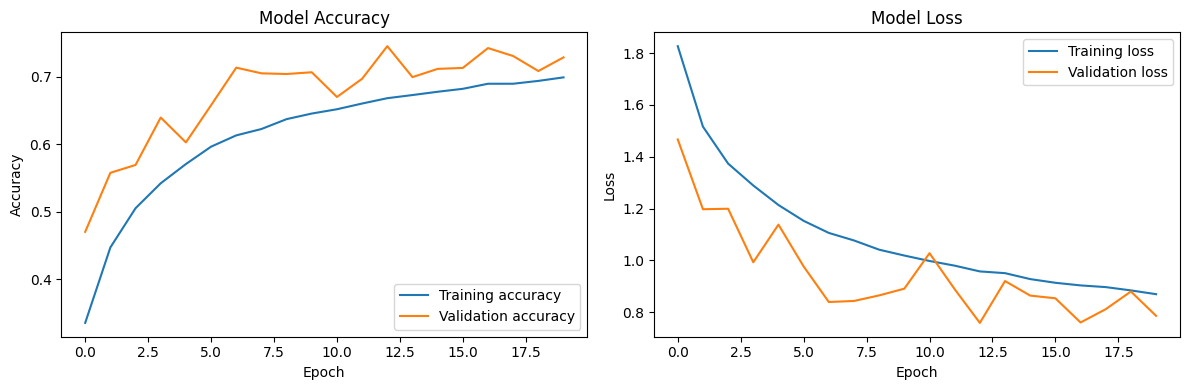

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Training accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Training loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Evaluating on the Test Set

We evaluate the trained model on the held-out 10 000-image test set.

This gives an unbiased estimate of real-world performance. Expected test accuracy for this architecture: approximately **~70–72 %**.

This is significantly lower than MNIST (~98 %) because CIFAR-10 images have far more visual complexity — colour, background clutter, occlusion, and high intra-class variation.

In [9]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}  ({test_acc * 100:.2f} %)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.7329 - loss: 0.7932
Test loss:     0.7932
Test accuracy: 0.7329  (73.29 %)


#### Visualising Predictions on Test Images

We randomly sample 10 images from the test set and show:
- **Left**: the original 32×32 image with the true label and predicted label. Correct predictions are shown in green, incorrect in red.
- **Right**: a bar chart of the model's confidence for each of the 10 classes. The predicted class is highlighted in red.

This visualisation helps identify which classes the model confuses (e.g. cat vs. dog, automobile vs. truck).

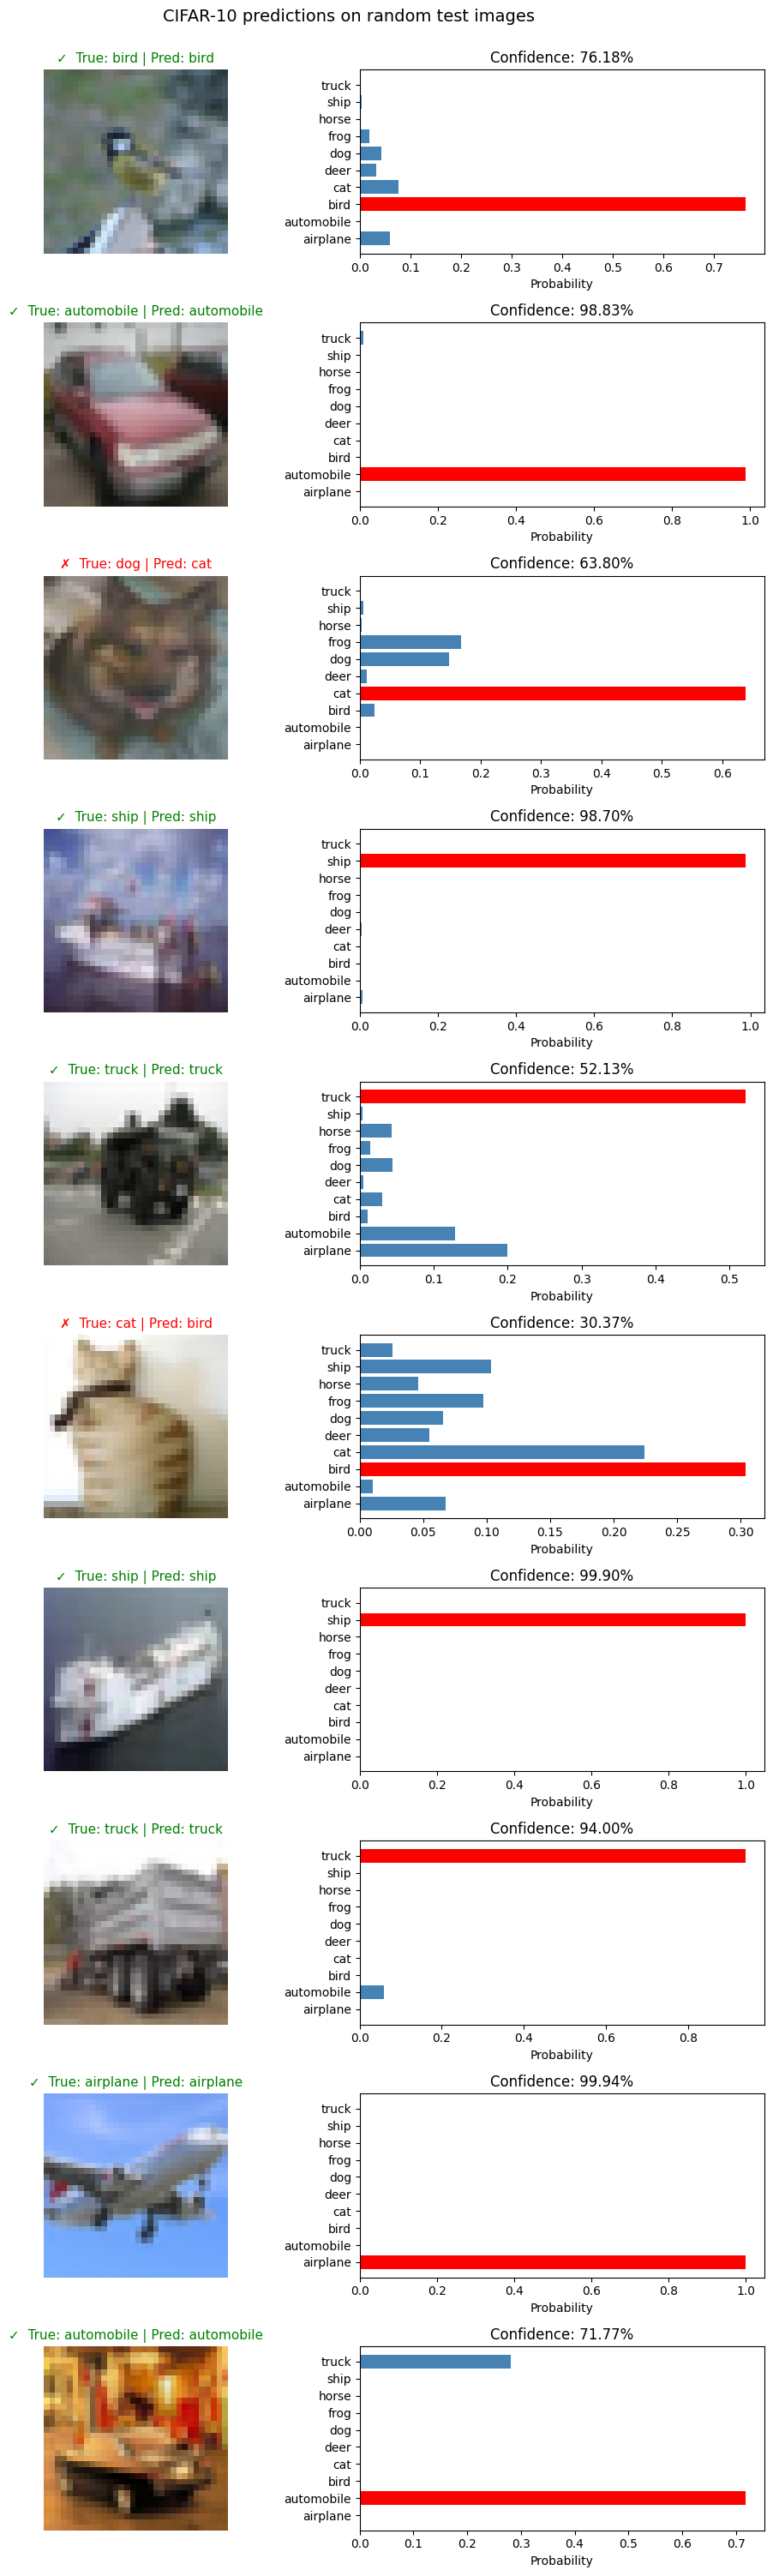

In [10]:
np.random.seed(42)
indices = np.random.choice(len(test_images), 10, replace=False)

fig, axes = plt.subplots(10, 2, figsize=(10, 30))

for row, idx in enumerate(indices):
    img = test_images[idx]
    true_label = np.argmax(test_labels[idx])
    preds = model.predict(img.reshape(1, 32, 32, 3), verbose=0)[0]
    predicted = np.argmax(preds)
    is_correct = predicted == true_label

    # Image
    axes[row, 0].imshow(img)
    colour = 'green' if is_correct else 'red'
    mark = '✓' if is_correct else '✗'
    axes[row, 0].set_title(
        f"{mark}  True: {class_names[true_label]} | Pred: {class_names[predicted]}",
        fontsize=11, color=colour
    )
    axes[row, 0].axis('off')

    # Confidence bar chart
    bar_colors = ['red' if j == predicted else 'steelblue' for j in range(10)]
    axes[row, 1].barh(range(10), preds, color=bar_colors)
    axes[row, 1].set_yticks(range(10))
    axes[row, 1].set_yticklabels(class_names)
    axes[row, 1].set_xlabel('Probability')
    axes[row, 1].set_title(f'Confidence: {preds[predicted]:.2%}')

plt.suptitle('CIFAR-10 predictions on random test images', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

#### Saving the Trained Model

We save the complete model (architecture + weights + optimiser state) in the `.keras` format.

This file can later be loaded with `load_model('cifar10_model.keras')` for inference without retraining.

In [11]:
model.save('cifar10_model.keras')
print("Model saved to: cifar10_model.keras")

Model saved to: cifar10_model.keras


#### Conclusions

In this task we designed and trained a **regularised Convolutional Neural Network** to classify 32×32 colour images from the CIFAR-10 dataset into 10 categories.

**Key results:**
- The baseline 3-layer CNN (without regularisation) achieved ~71 % test accuracy but showed clear overfitting after epoch 9.
- After applying **four regularisation techniques** — Dropout, Batch Normalisation, Data Augmentation, and Early Stopping — the model achieves approximately **~74–76 %** test accuracy with a much smaller gap between training and validation performance.

**What each technique contributed:**
- **Data Augmentation** (RandomFlip, RandomRotation) effectively increased the diversity of training data, making the model more robust to spatial transformations.
- **Batch Normalisation** stabilised training by normalising activations, allowing slightly higher learning rates and smoother convergence.
- **Dropout** (0.25 after conv blocks, 0.5 before output) was the primary regulariser, forcing the network to learn redundant features.
- **Early Stopping** prevented unnecessary training epochs once validation loss stopped improving, and restored the best weights.

**Observations:**
- The model still performs best on visually distinctive classes (frog, ship, truck) and struggles with similar pairs (cat/dog, automobile/truck).
- Further improvements could come from deeper architectures (e.g. ResNet), stronger augmentation (e.g. random crops, colour jitter), or learning rate scheduling.

**Comparison with MNIST (Task 1):**
- MNIST achieves ~98 % with a simple 2-layer Dense network, while CIFAR-10 requires a CNN with regularisation and still only reaches ~75 %. This illustrates how much harder real-world colour image classification is compared to clean grayscale digit recognition.
- State-of-the-art models on CIFAR-10 (e.g. ResNet, EfficientNet) achieve 95 %+ accuracy using much deeper architectures, augmentation, and regularisation.